# CSE 472 Assignment 2: Decision Trees, Random Forests, and Extra Trees

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
RANDOM_STATE = 42

## Decision Tree Implementation

In [2]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
    
    def is_leaf(self):
        return self.value is not None


class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, n_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.random_state = random_state
        self.root = None
        self.n_classes = None
        
    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        self.n_features = X.shape[1] if self.n_features is None else min(self.n_features, X.shape[1])
        if self.random_state is not None:
            np.random.seed(self.random_state)
        self.root = self._grow_tree(X, y, depth=0)
        
    def _grow_tree(self, X, y, depth):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))
        
        # Stopping criteria
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_labels == 1 or n_samples < self.min_samples_split:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # Select random features
        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)
        
        # Find best split
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)
        
        if best_feat is None:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # Create child nodes
        left_idxs = X[:, best_feat] <= best_thresh
        right_idxs = ~left_idxs
        
        if np.sum(left_idxs) == 0 or np.sum(right_idxs) == 0:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        return Node(best_feat, best_thresh, left, right)
    
    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        best_feat, best_thresh = None, None
        
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat_idx
                    best_thresh = threshold
        
        return best_feat, best_thresh
    
    def _gini(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return 1.0 - np.sum(ps ** 2)
    
    def _information_gain(self, y, X_column, threshold):
        parent_gini = self._gini(y)
        
        left_idxs = X_column <= threshold
        right_idxs = ~left_idxs
        
        if np.sum(left_idxs) == 0 or np.sum(right_idxs) == 0:
            return 0
        
        n = len(y)
        n_l, n_r = np.sum(left_idxs), np.sum(right_idxs)
        g_l, g_r = self._gini(y[left_idxs]), self._gini(y[right_idxs])
        child_gini = (n_l / n) * g_l + (n_r / n) * g_r
        
        return parent_gini - child_gini
    
    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]
    
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def predict_proba(self, X):
        predictions = self.predict(X)
        proba = np.zeros((len(X), self.n_classes))
        for i, pred in enumerate(predictions):
            proba[i, pred] = 1.0
        return proba

## Random Forest Implementation

In [3]:
class RandomForest:
    def __init__(self, n_trees=100, max_depth=None, min_samples_split=2, n_features=None, random_state=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.random_state = random_state
        self.trees = []
        self.n_classes = None
        
    def fit(self, X, y):
        self.trees = []
        self.n_classes = len(np.unique(y))
        n_samples = X.shape[0]
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        for i in range(self.n_trees):
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features,
                random_state=self.random_state + i if self.random_state else None
            )
            # Bootstrap sampling
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            tree.fit(X[idxs], y[idxs])
            self.trees.append(tree)
    
    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority voting
        predictions = []
        for i in range(X.shape[0]):
            votes = tree_preds[:, i]
            predictions.append(Counter(votes).most_common(1)[0][0])
        return np.array(predictions)
    
    def predict_proba(self, X):
        tree_probas = np.array([tree.predict_proba(X) for tree in self.trees])
        return np.mean(tree_probas, axis=0)

## Extra Trees Implementation

In [4]:
class ExtraTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
    
    def is_leaf(self):
        return self.value is not None


class ExtraTree:
    """Extremely Randomized Tree - picks random thresholds instead of optimal ones"""
    def __init__(self, max_depth=None, min_samples_split=2, n_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.random_state = random_state
        self.root = None
        self.n_classes = None
        
    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        self.n_features = X.shape[1] if self.n_features is None else min(self.n_features, X.shape[1])
        if self.random_state is not None:
            np.random.seed(self.random_state)
        self.root = self._grow_tree(X, y, depth=0)
        
    def _grow_tree(self, X, y, depth):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))
        
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_labels == 1 or n_samples < self.min_samples_split:
            leaf_value = self._most_common_label(y)
            return ExtraTreeNode(value=leaf_value)
        
        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)
        
        best_feat, best_thresh = self._best_split_random(X, y, feat_idxs)
        
        if best_feat is None:
            leaf_value = self._most_common_label(y)
            return ExtraTreeNode(value=leaf_value)
        
        left_idxs = X[:, best_feat] <= best_thresh
        right_idxs = ~left_idxs
        
        if np.sum(left_idxs) == 0 or np.sum(right_idxs) == 0:
            leaf_value = self._most_common_label(y)
            return ExtraTreeNode(value=leaf_value)
        
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        return ExtraTreeNode(best_feat, best_thresh, left, right)
    
    def _best_split_random(self, X, y, feat_idxs):
        """Key difference: randomly pick threshold for each feature"""
        best_gain = -1
        best_feat, best_thresh = None, None
        
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            min_val, max_val = X_column.min(), X_column.max()
            
            if min_val == max_val:
                continue
            
            # Randomly pick a threshold between min and max
            threshold = np.random.uniform(min_val, max_val)
            gain = self._information_gain(y, X_column, threshold)
            
            if gain > best_gain:
                best_gain = gain
                best_feat = feat_idx
                best_thresh = threshold
        
        return best_feat, best_thresh
    
    def _information_gain(self, y, X_column, threshold):
        parent_entropy = self._entropy(y)
        
        left_idxs = X_column <= threshold
        right_idxs = ~left_idxs
        
        if np.sum(left_idxs) == 0 or np.sum(right_idxs) == 0:
            return 0
        
        n = len(y)
        n_l, n_r = np.sum(left_idxs), np.sum(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r
        
        return parent_entropy - child_entropy
    
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
    
    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]
    
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def predict_proba(self, X):
        predictions = self.predict(X)
        proba = np.zeros((len(X), self.n_classes))
        for i, pred in enumerate(predictions):
            proba[i, pred] = 1.0
        return proba


class ExtraTrees:
    """Extremely Randomized Trees ensemble - no bootstrap, uses full dataset"""
    def __init__(self, n_trees=100, max_depth=None, min_samples_split=2, n_features=None, random_state=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.random_state = random_state
        self.trees = []
        self.n_classes = None
        
    def fit(self, X, y):
        self.trees = []
        self.n_classes = len(np.unique(y))
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        for i in range(self.n_trees):
            tree = ExtraTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features,
                random_state=self.random_state + i if self.random_state else None
            )
            # No bootstrap - uses full dataset
            tree.fit(X, y)
            self.trees.append(tree)
    
    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        predictions = []
        for i in range(X.shape[0]):
            votes = tree_preds[:, i]
            predictions.append(Counter(votes).most_common(1)[0][0])
        return np.array(predictions)
    
    def predict_proba(self, X):
        tree_probas = np.array([tree.predict_proba(X) for tree in self.trees])
        return np.mean(tree_probas, axis=0)

## Load Datasets

In [5]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=RANDOM_STATE, stratify=y_iris
)

wine = load_wine()
X_wine, y_wine = wine.data, wine.target
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=RANDOM_STATE, stratify=y_wine
)

print(f"Iris Dataset: Train={len(X_iris_train)}, Test={len(X_iris_test)}, Classes={len(np.unique(y_iris))}")
print(f"Wine Dataset: Train={len(X_wine_train)}, Test={len(X_wine_test)}, Classes={len(np.unique(y_wine))}")

Iris Dataset: Train=120, Test=30, Classes=3
Wine Dataset: Train=142, Test=36, Classes=3


## Evaluation Helper Functions

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, n_classes):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    try:
        y_proba = model.predict_proba(X_test)
        if y_proba.shape[1] == n_classes:
            auroc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        else:
            auroc = np.nan
    except:
        auroc = np.nan
    
    return {'Accuracy': acc, 'F1-Score': f1, 'AUROC': auroc}


def run_experiments(X_train, y_train, X_test, y_test, dataset_name):
    n_classes = len(np.unique(y_train))
    n_features = int(np.sqrt(X_train.shape[1]))
    
    results = {}
    
    # Custom Models
    print(f"Training Custom Decision Tree on {dataset_name}...")
    dt = DecisionTree(max_depth=10, min_samples_split=2, random_state=RANDOM_STATE)
    results['Custom DT'] = evaluate_model(dt, X_train, y_train, X_test, y_test, n_classes)
    
    print(f"Training Custom Random Forest on {dataset_name}...")
    rf = RandomForest(n_trees=200, max_depth=10, min_samples_split=2, 
                      n_features=n_features, random_state=RANDOM_STATE)
    results['Custom RF'] = evaluate_model(rf, X_train, y_train, X_test, y_test, n_classes)
    
    print(f"Training Custom Extra Trees on {dataset_name}...")
    et = ExtraTrees(n_trees=200, max_depth=10, min_samples_split=2, 
                    n_features=n_features, random_state=RANDOM_STATE)
    results['Custom ET'] = evaluate_model(et, X_train, y_train, X_test, y_test, n_classes)
    
    # Sklearn Models
    print(f"Training Sklearn Decision Tree on {dataset_name}...")
    sklearn_dt = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=RANDOM_STATE)
    results['Sklearn DT'] = evaluate_model(sklearn_dt, X_train, y_train, X_test, y_test, n_classes)
    
    print(f"Training Sklearn Random Forest on {dataset_name}...")
    sklearn_rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, 
                                        max_features=n_features, random_state=RANDOM_STATE)
    results['Sklearn RF'] = evaluate_model(sklearn_rf, X_train, y_train, X_test, y_test, n_classes)
    
    print(f"Training Sklearn Extra Trees on {dataset_name}...")
    sklearn_et = ExtraTreesClassifier(n_estimators=200, max_depth=10, min_samples_split=2, 
                                      max_features=n_features, random_state=RANDOM_STATE)
    results['Sklearn ET'] = evaluate_model(sklearn_et, X_train, y_train, X_test, y_test, n_classes)
    
    return results

## Experiments on Iris Dataset

In [7]:
iris_results = run_experiments(X_iris_train, y_iris_train, X_iris_test, y_iris_test, "Iris")
iris_df = pd.DataFrame(iris_results).T
iris_df = iris_df.round(4)
print("\n=== Iris Dataset Results ===")
iris_df

Training Custom Decision Tree on Iris...
Training Custom Random Forest on Iris...
Training Custom Extra Trees on Iris...
Training Sklearn Decision Tree on Iris...
Training Sklearn Random Forest on Iris...
Training Sklearn Extra Trees on Iris...

=== Iris Dataset Results ===


,Accuracy,F1-Score,AUROC
Custom DT,0.9000,0.8997,0.9250
Custom RF,0.9667,0.9666,0.9842
Custom ET,0.9667,0.9666,0.9933
Sklearn DT,0.9333,0.9333,0.9500
Sklearn RF,0.9000,0.8997,0.9867
Sklearn ET,0.9333,0.9333,0.9933


## Experiments on Wine Dataset

In [8]:
wine_results = run_experiments(X_wine_train, y_wine_train, X_wine_test, y_wine_test, "Wine")
wine_df = pd.DataFrame(wine_results).T
wine_df = wine_df.round(4)
print("\n=== Wine Dataset Results ===")
wine_df

Training Custom Decision Tree on Wine...
Training Custom Random Forest on Wine...
Training Custom Extra Trees on Wine...
Training Sklearn Decision Tree on Wine...
Training Sklearn Random Forest on Wine...
Training Sklearn Extra Trees on Wine...

=== Wine Dataset Results ===


,Accuracy,F1-Score,AUROC
Custom DT,0.9167,0.9168,0.9356
Custom RF,1.0000,1.0000,1.0000
Custom ET,1.0000,1.0000,1.0000
Sklearn DT,0.9444,0.9450,0.9545
Sklearn RF,1.0000,1.0000,1.0000
Sklearn ET,1.0000,1.0000,1.0000


## Results Comparison - Visualizations

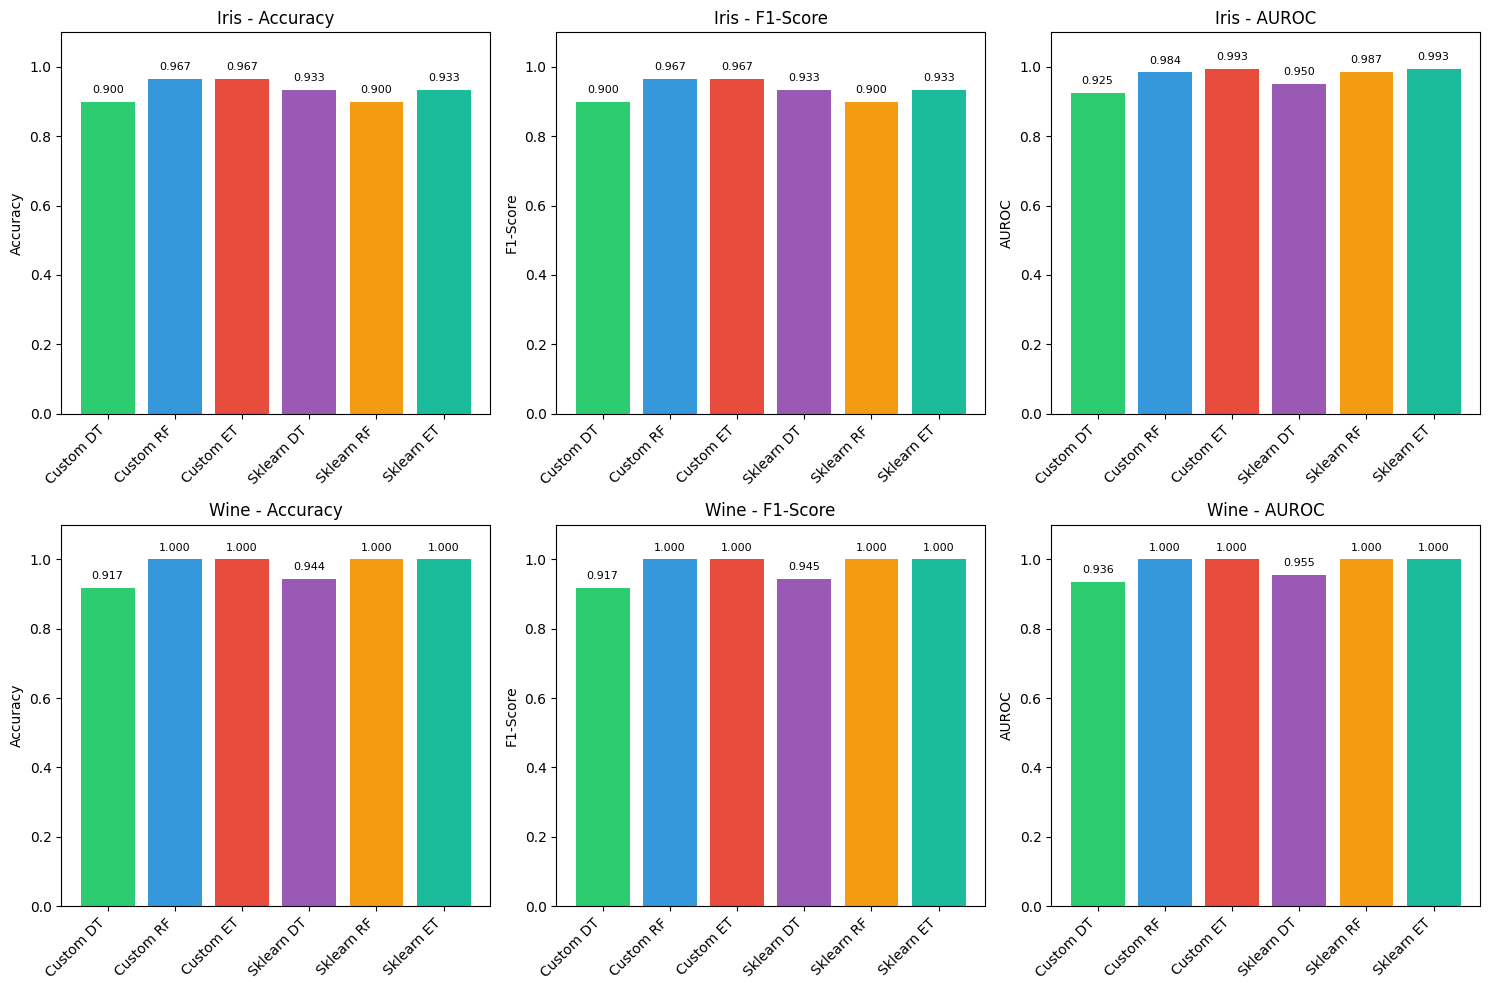

In [9]:
def plot_comparison(iris_df, wine_df):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    metrics = ['Accuracy', 'F1-Score', 'AUROC']
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']
    
    for i, metric in enumerate(metrics):
        # Iris
        ax = axes[0, i]
        x = np.arange(len(iris_df))
        bars = ax.bar(x, iris_df[metric], color=colors)
        ax.set_ylabel(metric)
        ax.set_title(f'Iris - {metric}')
        ax.set_xticks(x)
        ax.set_xticklabels(iris_df.index, rotation=45, ha='right')
        ax.set_ylim(0, 1.1)
        for bar, val in zip(bars, iris_df[metric]):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                       f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        
        # Wine
        ax = axes[1, i]
        bars = ax.bar(x, wine_df[metric], color=colors)
        ax.set_ylabel(metric)
        ax.set_title(f'Wine - {metric}')
        ax.set_xticks(x)
        ax.set_xticklabels(wine_df.index, rotation=45, ha='right')
        ax.set_ylim(0, 1.1)
        for bar, val in zip(bars, wine_df[metric]):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                       f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison(iris_df, wine_df)

## Custom vs Sklearn Comparison

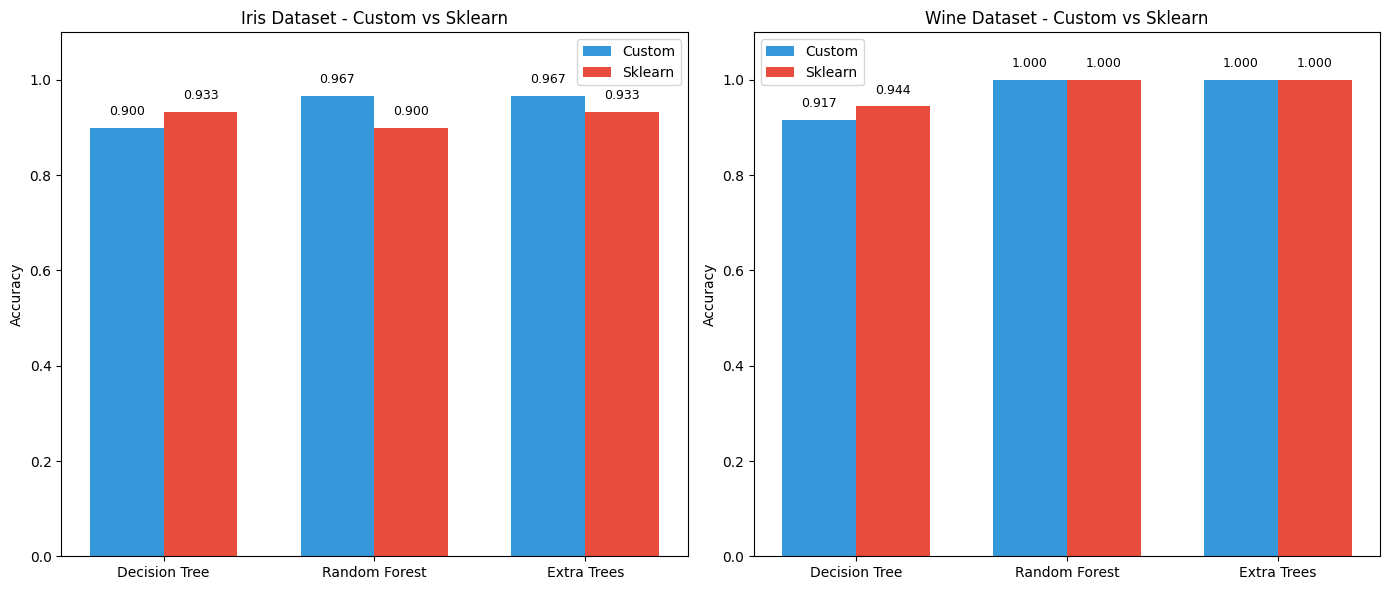

In [10]:
def plot_custom_vs_sklearn(iris_df, wine_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Grouped bar chart for Accuracy comparison
    models = ['Decision Tree', 'Random Forest', 'Extra Trees']
    x = np.arange(len(models))
    width = 0.35
    
    # Iris
    ax = axes[0]
    custom_acc = [iris_df.loc['Custom DT', 'Accuracy'], 
                  iris_df.loc['Custom RF', 'Accuracy'], 
                  iris_df.loc['Custom ET', 'Accuracy']]
    sklearn_acc = [iris_df.loc['Sklearn DT', 'Accuracy'], 
                   iris_df.loc['Sklearn RF', 'Accuracy'], 
                   iris_df.loc['Sklearn ET', 'Accuracy']]
    
    bars1 = ax.bar(x - width/2, custom_acc, width, label='Custom', color='#3498db')
    bars2 = ax.bar(x + width/2, sklearn_acc, width, label='Sklearn', color='#e74c3c')
    ax.set_ylabel('Accuracy')
    ax.set_title('Iris Dataset - Custom vs Sklearn')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim(0, 1.1)
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
               f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
               f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    
    # Wine
    ax = axes[1]
    custom_acc = [wine_df.loc['Custom DT', 'Accuracy'], 
                  wine_df.loc['Custom RF', 'Accuracy'], 
                  wine_df.loc['Custom ET', 'Accuracy']]
    sklearn_acc = [wine_df.loc['Sklearn DT', 'Accuracy'], 
                   wine_df.loc['Sklearn RF', 'Accuracy'], 
                   wine_df.loc['Sklearn ET', 'Accuracy']]
    
    bars1 = ax.bar(x - width/2, custom_acc, width, label='Custom', color='#3498db')
    bars2 = ax.bar(x + width/2, sklearn_acc, width, label='Sklearn', color='#e74c3c')
    ax.set_ylabel('Accuracy')
    ax.set_title('Wine Dataset - Custom vs Sklearn')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim(0, 1.1)
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
               f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
               f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('custom_vs_sklearn.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_custom_vs_sklearn(iris_df, wine_df)

## Heatmap Comparison

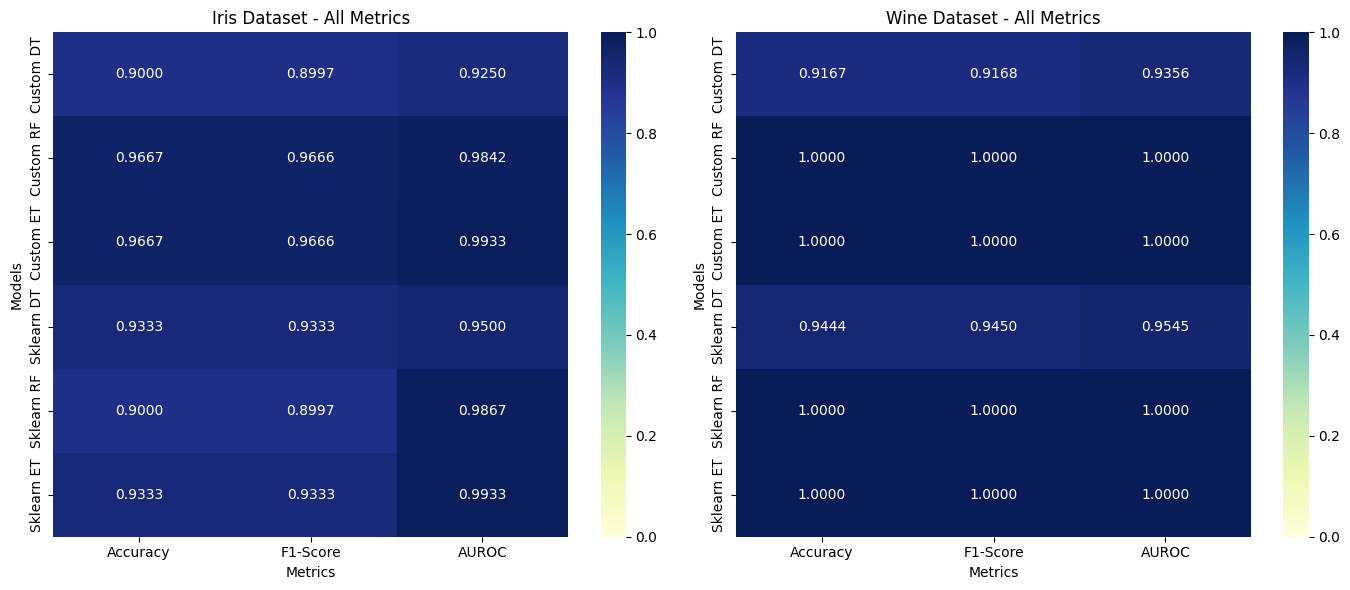

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Iris heatmap
ax = axes[0]
sns.heatmap(iris_df, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax, vmin=0, vmax=1)
ax.set_title('Iris Dataset - All Metrics')
ax.set_xlabel('Metrics')
ax.set_ylabel('Models')

# Wine heatmap
ax = axes[1]
sns.heatmap(wine_df, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax, vmin=0, vmax=1)
ax.set_title('Wine Dataset - All Metrics')
ax.set_xlabel('Metrics')
ax.set_ylabel('Models')

plt.tight_layout()
plt.savefig('heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Decision Tree vs Ensemble Methods

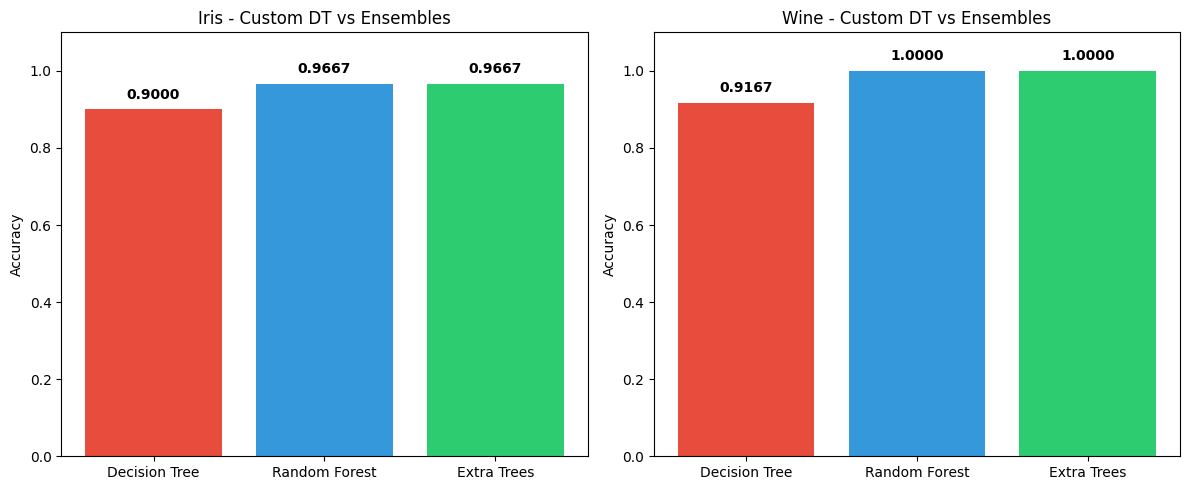

In [12]:
def plot_dt_vs_ensemble(iris_df, wine_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Iris
    ax = axes[0]
    dt_acc = iris_df.loc['Custom DT', 'Accuracy']
    rf_acc = iris_df.loc['Custom RF', 'Accuracy']
    et_acc = iris_df.loc['Custom ET', 'Accuracy']
    
    methods = ['Decision Tree', 'Random Forest', 'Extra Trees']
    accs = [dt_acc, rf_acc, et_acc]
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    
    bars = ax.bar(methods, accs, color=colors)
    ax.set_ylabel('Accuracy')
    ax.set_title('Iris - Custom DT vs Ensembles')
    ax.set_ylim(0, 1.1)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
               f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Wine
    ax = axes[1]
    dt_acc = wine_df.loc['Custom DT', 'Accuracy']
    rf_acc = wine_df.loc['Custom RF', 'Accuracy']
    et_acc = wine_df.loc['Custom ET', 'Accuracy']
    
    accs = [dt_acc, rf_acc, et_acc]
    
    bars = ax.bar(methods, accs, color=colors)
    ax.set_ylabel('Accuracy')
    ax.set_title('Wine - Custom DT vs Ensembles')
    ax.set_ylim(0, 1.1)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
               f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('dt_vs_ensemble.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_dt_vs_ensemble(iris_df, wine_df)

## Hyperparameter Analysis: Effect of Number of Trees

In [13]:
def analyze_n_trees(X_train, y_train, X_test, y_test, dataset_name):
    n_trees_range = [1, 5, 10, 25, 50, 100, 150, 200]
    n_features = int(np.sqrt(X_train.shape[1]))
    
    rf_accuracies = []
    et_accuracies = []
    
    for n_trees in n_trees_range:
        # Random Forest
        rf = RandomForest(n_trees=n_trees, max_depth=10, n_features=n_features, random_state=RANDOM_STATE)
        rf.fit(X_train, y_train)
        rf_accuracies.append(accuracy_score(y_test, rf.predict(X_test)))
        
        # Extra Trees
        et = ExtraTrees(n_trees=n_trees, max_depth=10, n_features=n_features, random_state=RANDOM_STATE)
        et.fit(X_train, y_train)
        et_accuracies.append(accuracy_score(y_test, et.predict(X_test)))
    
    return n_trees_range, rf_accuracies, et_accuracies

print("Analyzing effect of number of trees on Iris...")
iris_n_trees, iris_rf_acc, iris_et_acc = analyze_n_trees(X_iris_train, y_iris_train, X_iris_test, y_iris_test, "Iris")

print("Analyzing effect of number of trees on Wine...")
wine_n_trees, wine_rf_acc, wine_et_acc = analyze_n_trees(X_wine_train, y_wine_train, X_wine_test, y_wine_test, "Wine")

Analyzing effect of number of trees on Iris...
Analyzing effect of number of trees on Wine...


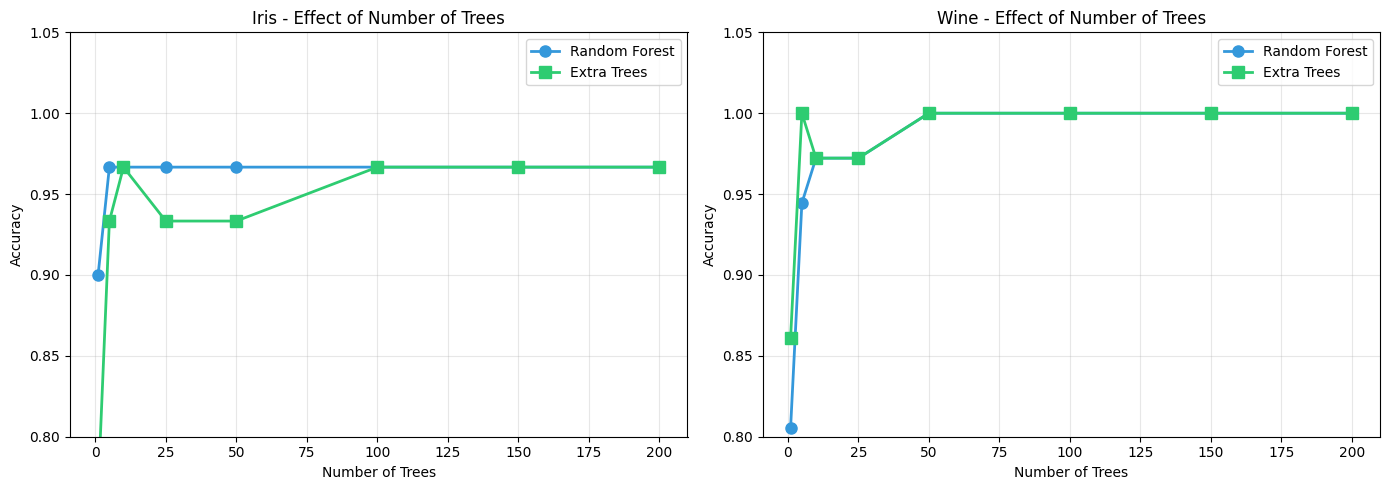

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iris
ax = axes[0]
ax.plot(iris_n_trees, iris_rf_acc, 'o-', label='Random Forest', color='#3498db', linewidth=2, markersize=8)
ax.plot(iris_n_trees, iris_et_acc, 's-', label='Extra Trees', color='#2ecc71', linewidth=2, markersize=8)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Accuracy')
ax.set_title('Iris - Effect of Number of Trees')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.8, 1.05)

# Wine
ax = axes[1]
ax.plot(wine_n_trees, wine_rf_acc, 'o-', label='Random Forest', color='#3498db', linewidth=2, markersize=8)
ax.plot(wine_n_trees, wine_et_acc, 's-', label='Extra Trees', color='#2ecc71', linewidth=2, markersize=8)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Accuracy')
ax.set_title('Wine - Effect of Number of Trees')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.8, 1.05)

plt.tight_layout()
plt.savefig('n_trees_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Effect of Max Depth

In [15]:
def analyze_max_depth(X_train, y_train, X_test, y_test):
    depths = [1, 2, 3, 4, 5, 7, 10, 15, 20, None]
    depth_labels = [str(d) if d else 'None' for d in depths]
    
    dt_train_acc = []
    dt_test_acc = []
    
    for depth in depths:
        dt = DecisionTree(max_depth=depth, min_samples_split=2, random_state=RANDOM_STATE)
        dt.fit(X_train, y_train)
        dt_train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
        dt_test_acc.append(accuracy_score(y_test, dt.predict(X_test)))
    
    return depth_labels, dt_train_acc, dt_test_acc

print("Analyzing effect of max depth...")
iris_depths, iris_train, iris_test = analyze_max_depth(X_iris_train, y_iris_train, X_iris_test, y_iris_test)
wine_depths, wine_train, wine_test = analyze_max_depth(X_wine_train, y_wine_train, X_wine_test, y_wine_test)

Analyzing effect of max depth...


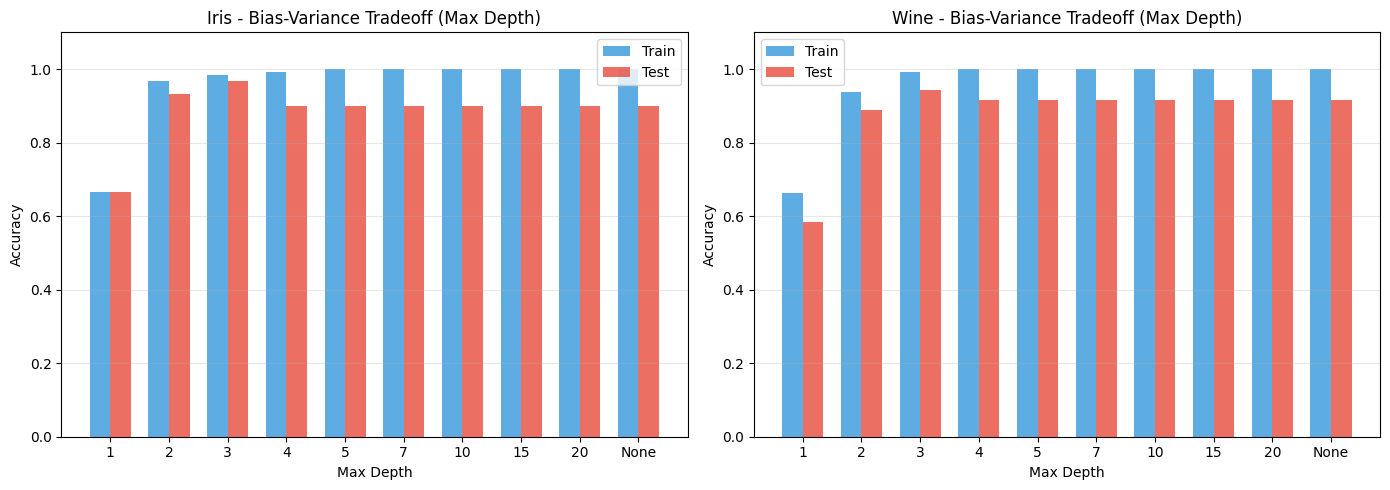

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iris
ax = axes[0]
x = np.arange(len(iris_depths))
width = 0.35
ax.bar(x - width/2, iris_train, width, label='Train', color='#3498db', alpha=0.8)
ax.bar(x + width/2, iris_test, width, label='Test', color='#e74c3c', alpha=0.8)
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Iris - Bias-Variance Tradeoff (Max Depth)')
ax.set_xticks(x)
ax.set_xticklabels(iris_depths)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Wine
ax = axes[1]
ax.bar(x - width/2, wine_train, width, label='Train', color='#3498db', alpha=0.8)
ax.bar(x + width/2, wine_test, width, label='Test', color='#e74c3c', alpha=0.8)
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Wine - Bias-Variance Tradeoff (Max Depth)')
ax.set_xticks(x)
ax.set_xticklabels(wine_depths)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('max_depth_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Effect of n_estimators on Random Forest (Custom vs Sklearn)

In [17]:
n_estimators_range = [1, 5, 10, 25, 50, 75, 100, 150, 200, 250, 300]

# Iris dataset
iris_custom_rf_acc = []
iris_sklearn_rf_acc = []

print("Analyzing n_estimators effect on Iris dataset...")
for n in n_estimators_range:
    # Custom RF
    rf_custom = RandomForest(n_trees=n, max_depth=10, min_samples_split=2, 
                              n_features=int(np.sqrt(X_iris_train.shape[1])), random_state=RANDOM_STATE)
    rf_custom.fit(X_iris_train, y_iris_train)
    iris_custom_rf_acc.append(accuracy_score(y_iris_test, rf_custom.predict(X_iris_test)))
    
    # Sklearn RF
    rf_sklearn = RandomForestClassifier(n_estimators=n, max_depth=10, min_samples_split=2,
                                         max_features=int(np.sqrt(X_iris_train.shape[1])), random_state=RANDOM_STATE)
    rf_sklearn.fit(X_iris_train, y_iris_train)
    iris_sklearn_rf_acc.append(accuracy_score(y_iris_test, rf_sklearn.predict(X_iris_test)))

# Wine dataset
wine_custom_rf_acc = []
wine_sklearn_rf_acc = []

print("Analyzing n_estimators effect on Wine dataset...")
for n in n_estimators_range:
    # Custom RF
    rf_custom = RandomForest(n_trees=n, max_depth=10, min_samples_split=2,
                              n_features=int(np.sqrt(X_wine_train.shape[1])), random_state=RANDOM_STATE)
    rf_custom.fit(X_wine_train, y_wine_train)
    wine_custom_rf_acc.append(accuracy_score(y_wine_test, rf_custom.predict(X_wine_test)))
    
    # Sklearn RF
    rf_sklearn = RandomForestClassifier(n_estimators=n, max_depth=10, min_samples_split=2,
                                         max_features=int(np.sqrt(X_wine_train.shape[1])), random_state=RANDOM_STATE)
    rf_sklearn.fit(X_wine_train, y_wine_train)
    wine_sklearn_rf_acc.append(accuracy_score(y_wine_test, rf_sklearn.predict(X_wine_test)))

print("Done!")

Analyzing n_estimators effect on Iris dataset...
Analyzing n_estimators effect on Wine dataset...
Done!


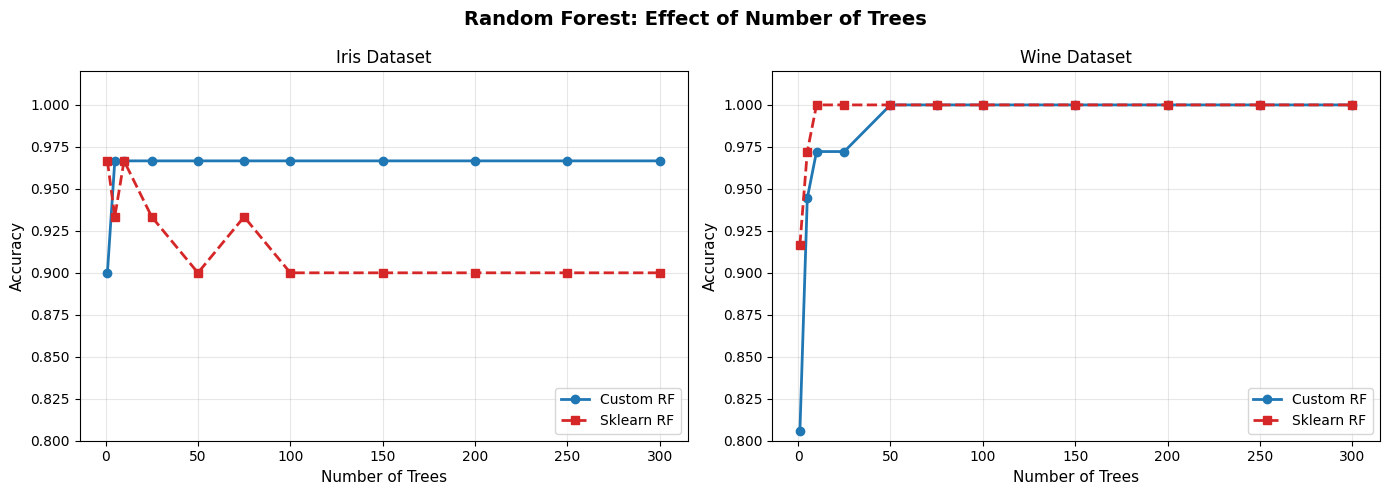

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest: Effect of Number of Trees', fontsize=14, fontweight='bold')

# Iris
axes[0].plot(n_estimators_range, iris_custom_rf_acc, 'o-', label='Custom RF', color='#1f77b4', linewidth=2, markersize=6)
axes[0].plot(n_estimators_range, iris_sklearn_rf_acc, 's--', label='Sklearn RF', color='#d62728', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of Trees', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Iris Dataset', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.8, 1.02])

# Wine
axes[1].plot(n_estimators_range, wine_custom_rf_acc, 'o-', label='Custom RF', color='#1f77b4', linewidth=2, markersize=6)
axes[1].plot(n_estimators_range, wine_sklearn_rf_acc, 's--', label='Sklearn RF', color='#d62728', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of Trees', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Wine Dataset', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.8, 1.02])

plt.tight_layout()
plt.show()

## Combined Results Table

In [19]:
iris_df_labeled = iris_df.copy()
iris_df_labeled.columns = [f'Iris_{col}' for col in iris_df_labeled.columns]

wine_df_labeled = wine_df.copy()
wine_df_labeled.columns = [f'Wine_{col}' for col in wine_df_labeled.columns]

combined_df = pd.concat([iris_df_labeled, wine_df_labeled], axis=1)
print("Combined Results for Both Datasets:")
combined_df

Combined Results for Both Datasets:


,Iris_Accuracy,Iris_F1-Score,Iris_AUROC,Wine_Accuracy,Wine_F1-Score,Wine_AUROC
Custom DT,0.9000,0.8997,0.9250,0.9167,0.9168,0.9356
Custom RF,0.9667,0.9666,0.9842,1.0000,1.0000,1.0000
Custom ET,0.9667,0.9666,0.9933,1.0000,1.0000,1.0000
Sklearn DT,0.9333,0.9333,0.9500,0.9444,0.9450,0.9545
Sklearn RF,0.9000,0.8997,0.9867,1.0000,1.0000,1.0000
Sklearn ET,0.9333,0.9333,0.9933,1.0000,1.0000,1.0000
